<a href="https://colab.research.google.com/github/lkssraw-7/shot-logs-nba/blob/main/Copy_of_Atividade_1_BigData_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Configuração Inicial e Carregamento de Dados

Esta seção inclui a importação das bibliotecas necessárias e o carregamento inicial do dataset, além de uma breve exploração para entender sua estrutura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('shot_logs.csv')
df=df.dropna()
print("Primeiras linhas da base:")
print(df.head())

print("\nDimensão da base:")
print(df.shape)

print("\nInformações da base:")
print(df.info())



Primeiras linhas da base:
    GAME_ID                   MATCHUP LOCATION  W  FINAL_MARGIN  SHOT_NUMBER  \
0  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            1   
1  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            2   
3  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            4   
4  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            5   
5  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            6   

   PERIOD GAME_CLOCK  SHOT_CLOCK  DRIBBLES  ...  SHOT_DIST  PTS_TYPE  \
0       1       1:09        10.8         2  ...        7.7         2   
1       1       0:14         3.4         0  ...       28.2         3   
3       2      11:47        10.3         2  ...       17.2         2   
4       2      10:34        10.9         2  ...        3.7         2   
5       2       8:15         9.1         2  ...       18.4         2   

   SHOT_RESULT   CLOSEST_DEFENDER CLOSEST_DEFENDER_PLAYER_ID

## 2. Preparação e Seleção de Atributos

Nesta parte, os dados são preparados, incluindo a seleção das colunas relevantes para as análises subsequentes.

In [3]:
df = df[['player_name','SHOT_DIST','PTS_TYPE', 'SHOT_RESULT','CLOSEST_DEFENDER','CLOSE_DEF_DIST', 'FGM']]
df

,player_name,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSE_DEF_DIST,FGM
0,brian roberts,7.7,2,made,"Anderson, Alan",1.3,1.0
1,brian roberts,28.2,3,missed,"Bogdanovic, Bojan",6.1,0.0
3,brian roberts,17.2,2,missed,"Brown, Markel",3.4,0.0
4,brian roberts,3.7,2,missed,"Young, Thaddeus",1.1,0.0
5,brian roberts,18.4,2,missed,"Williams, Deron",2.6,0.0
...,...,...,...,...,...,...,...
106257,steve adams,3.4,2,missed,"Sanders, Larry",2.2,0.0
106258,steve adams,8.0,2,missed,"Pachulia, Zaza",2.0,0.0
106259,steve adams,6.9,2,made,"Cousins, DeMarcus",2.0,1.0
106260,steve adams,7.0,2,missed,"Cousins, DeMarcus",3.2,0.0


## 3. Análise de Métricas Chave e Estatísticas de Jogadores

Esta seção foca na extração de métricas importantes, como a taxa geral de acerto, eficiência por tipo e distância de arremesso, e estatísticas sobre jogadores e defensores.

In [4]:
print("\nTaxa geral de acerto:")
print(df['FGM'].mean())



print("\nEficiência por tipo de arremesso:")
print(df.groupby('PTS_TYPE')['FGM'].mean())


print("\nEficiência por distância do arremesso:")
print(df.groupby(pd.cut(df['SHOT_DIST'], bins=5))['FGM'].mean())


print("\nEficiência por distância do defensor:")
print(df.groupby(pd.cut(df['CLOSE_DEF_DIST'], bins=5))['FGM'].mean())


print("\nTop 10 jogadores com mais arremessos:")
print(df['player_name'].value_counts().head(10))


tentativas = df['player_name'].value_counts()
players_validos1 = tentativas[tentativas > 50].index

print("\nJogadores mais eficientes (mínimo 50 arremessos):")
print(df[df['player_name'].isin(players_validos1)]
      .groupby('player_name')['FGM']
      .mean()
      .sort_values(ascending=False)
      .head(10))


print("\nDefensores que mais aparecem nos arremessos:")
print(df['CLOSEST_DEFENDER'].value_counts().head(10))






Taxa geral de acerto:
0.45627683460038604

Eficiência por tipo de arremesso:
PTS_TYPE
2    0.489677
3    0.360364
Name: FGM, dtype: float64

Eficiência por distância do arremesso:
SHOT_DIST
(-0.0435, 8.7]    0.555908
(8.7, 17.4]       0.410347
(17.4, 26.1]      0.378011
(26.1, 34.8]      0.301982
(34.8, 43.5]      0.217391
Name: FGM, dtype: float64

Eficiência por distância do defensor:
CLOSE_DEF_DIST
(-0.0532, 10.64]    0.455032
(10.64, 21.28]      0.488881
(21.28, 31.92]      0.714286
(31.92, 42.56]      1.000000
(42.56, 53.2]       1.000000
Name: FGM, dtype: float64

Top 10 jogadores com mais arremessos:
player_name
james harden         1006
mnta ellis           1004
klay thompson         953
lebron james          947
russell westbrook     943
stephen curry         941
kyrie irving          919
nikola vucevic        889
tyreke evans          875
rudy gay              861
Name: count, dtype: int64

Jogadores mais eficientes (mínimo 50 arremessos):
player_name
tyson chandler     0.68

/tmp/ipykernel_256/921419663.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['SHOT_DIST'], bins=5))['FGM'].mean())
/tmp/ipykernel_256/921419663.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['CLOSE_DEF_DIST'], bins=5))['FGM'].mean())


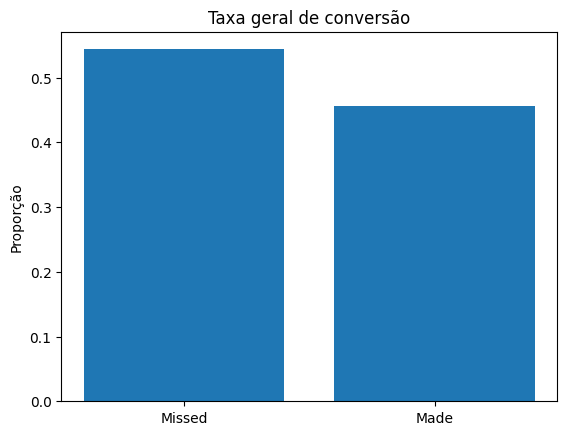

In [5]:
fgm_counts = df['FGM'].value_counts(normalize=True)

plt.figure()
plt.bar(['Missed','Made'], [fgm_counts.get(0,0), fgm_counts.get(1,0)])
plt.title("Taxa geral de conversão")
plt.ylabel("Proporção")
plt.show()


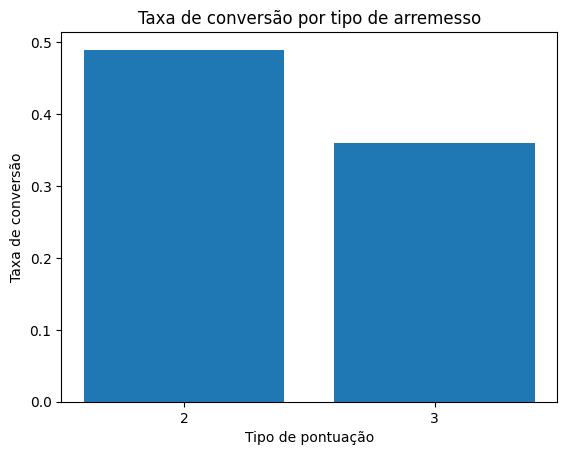

In [6]:
pts_eff = df.groupby('PTS_TYPE')['FGM'].mean()

plt.figure()
plt.bar(pts_eff.index.astype(str), pts_eff.values)
plt.title("Taxa de conversão por tipo de arremesso")
plt.xlabel("Tipo de pontuação")
plt.ylabel("Taxa de conversão")
plt.show()

/tmp/ipykernel_256/3919831757.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_eff = df.groupby(dist_bins)['FGM'].mean()


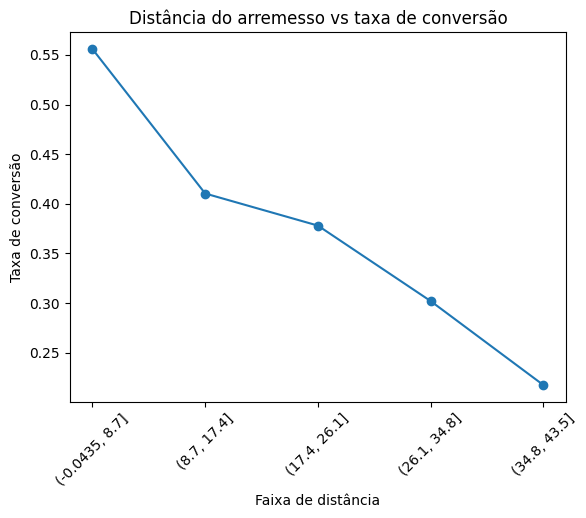

In [7]:
dist_bins = pd.cut(df['SHOT_DIST'], bins=5)
dist_eff = df.groupby(dist_bins)['FGM'].mean()

plt.figure()
plt.plot(dist_eff.index.astype(str), dist_eff.values, marker='o')
plt.xticks(rotation=45)
plt.title("Distância do arremesso vs taxa de conversão")
plt.xlabel("Faixa de distância")
plt.ylabel("Taxa de conversão")
plt.show()

/tmp/ipykernel_256/2739181510.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def_eff = df.groupby(def_bins)['FGM'].mean()


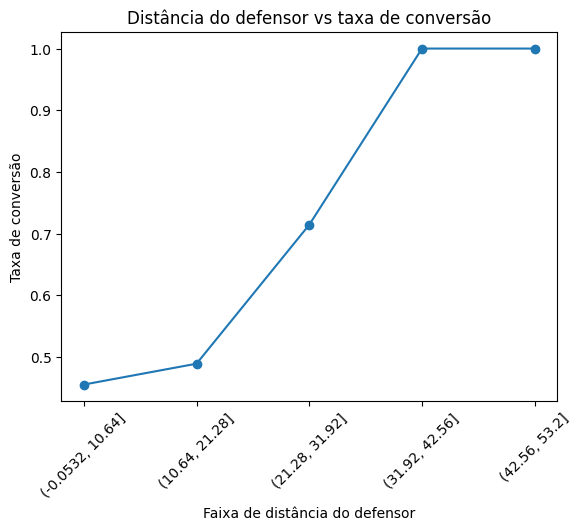

In [8]:
# Distância do defensor
def_bins = pd.cut(df['CLOSE_DEF_DIST'], bins=5)
def_eff = df.groupby(def_bins)['FGM'].mean()

plt.figure()
plt.plot(def_eff.index.astype(str), def_eff.values, marker='o')
plt.xticks(rotation=45)
plt.title("Distância do defensor vs taxa de conversão")
plt.xlabel("Faixa de distância do defensor")
plt.ylabel("Taxa de conversão")
plt.show()


## 4. Visualizações

Esta parte é dedicada à criação de gráficos e visualizações para ilustrar as métricas e tendências identificadas nas análises.

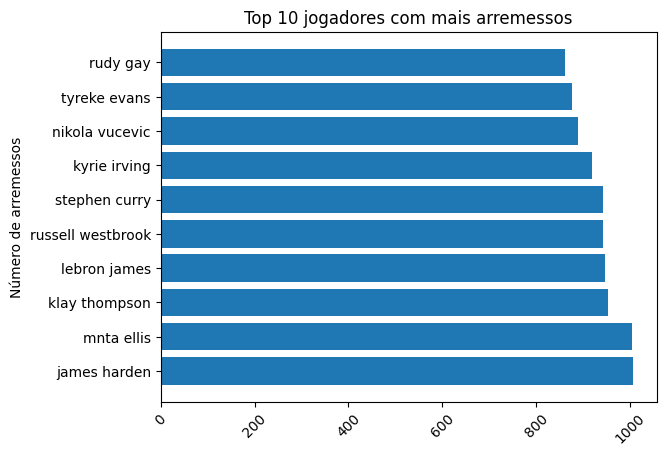

In [9]:
# Top jogadores com mais arremessos
mais_arremesos = df['player_name'].value_counts().head(10)

plt.figure()
plt.barh(mais_arremesos.index, mais_arremesos.values)
plt.xticks(rotation=45)
plt.title("Top 10 jogadores com mais arremessos")
plt.ylabel("Número de arremessos")
plt.show()

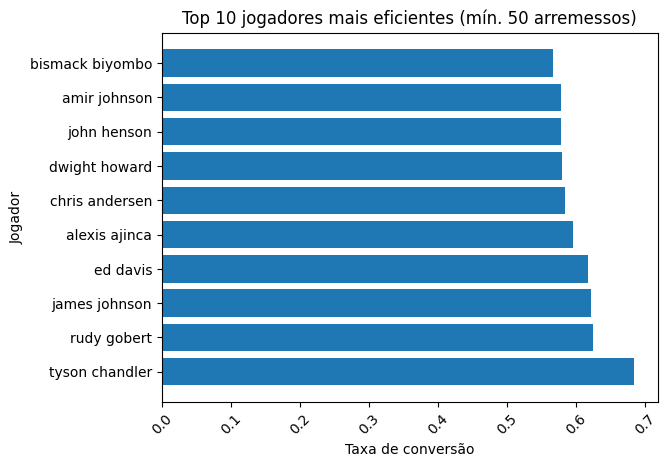

In [10]:
#Top jogadores com mais taxa de conversão

tentativas = df['player_name'].value_counts()

players_validos2 = tentativas[tentativas >= 50].index

mais_conversao = (
    df[df['player_name'].isin(players_validos2)]
    .groupby('player_name')['FGM']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()

plt.barh(mais_conversao.index, mais_conversao.values)

plt.xticks(rotation=45)
plt.title("Top 10 jogadores mais eficientes (mín. 50 arremessos)")
plt.ylabel("Jogador")
plt.xlabel("Taxa de conversão")

plt.show()

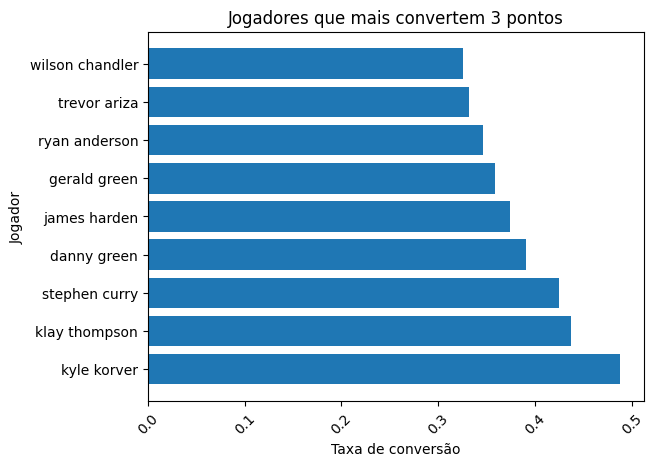

In [11]:
df_3pt = df[df['PTS_TYPE']==3]

tentativas_3pt = df_3pt['player_name'].value_counts()

players_validos3 = tentativas_3pt[tentativas_3pt >= 300].index

top_3pt = (
    df_3pt[df_3pt['player_name'].isin(players_validos3)]
    .groupby('player_name')['FGM']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    )

plt.figure()
plt.barh(top_3pt.index, top_3pt.values)
plt.xticks(rotation=45)
plt.title('Jogadores que mais convertem 3 pontos')
plt.xlabel('Taxa de conversão')
plt.ylabel('Jogador')
plt.show()

In [12]:
pip install mplbasketball

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4

In [13]:
from mplbasketball import Court